Quanitfy the difference between two ShakeMaps. To be run in env `shakemap`


## Read in and prepare datasets

In [16]:
#!/usr/bin/env python
"""
Compare two shakemaps.
"""
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from mapio.shake import ShakeGrid

# -------------------------
# USER INPUT
# -------------------------

# eventlist = [
#     'us6000jlqa',
#     "us60007idc",
#     "ci38457511",
# ]

# eventlist = [
#     'us6000n8tq',
#     'us6000qw60',
# ]
# eventtypelist = [
#     ''
# ]
# eventid = 'us2000d7q6'
eventid= 'us6000jllz'
# eventid='us60007idc'
# eventid='us1000h3p4'

eventtype='np2'    # 'np1-2', 'slab2', 


datadir = '/Users/hyin/shakemap_profiles/default/data/'
grid1=f'/Users/hyin/shakemap_profiles/default/data/{eventid}/ffsimmer_pointsource/products/grid.xml'
grid2 = f'/Users/hyin/shakemap_profiles/default/data/{eventid}/{eventtype}/products/grid.xml'
grid3 = f'/Users/hyin/shakemap_profiles/default/data/{eventid}/shakemap_reproduction/products/grid.xml'
# grid4 = '/Users/hyin/shakemap_profiles/default/data/us7000pn9s/shakemap_reproduction/products/grid.xml'

grid_files = [
    grid1,
    grid2,
    grid3,
    # grid4,
]
labels = ["Unconstrained",f"{eventtype}","Finite Fault"]

imt = "mmi"
output = f'/Users/hyin/shakemap_profiles/default/data/{eventid}/comparison/'

n = len(grid_files)


## Load grids

In [17]:
import xarray as xr
import numpy as np

def grid_to_xarray(grid, name="mmi"):
    gd = grid.getGeoDict()
    data = grid.getData()

    lats = gd.ymin + np.arange(gd.ny) * gd.dy
    lons = gd.xmin + np.arange(gd.nx) * gd.dx

    return xr.DataArray(
        data,
        coords={"lat": lats, "lon": lons},
        dims=("lat", "lon"),
        name=name
    )

# -------------------------
# LOAD GRIDS
# -------------------------
grids = [ShakeGrid.load(f).getData()[imt] for f in grid_files]

xr_grids = [grid_to_xarray(g,name=imt) for g in grids]

# Sanity check on grid extents and spcaing
for i, da in enumerate(xr_grids):
    print(f"\nGrid {labels[i]}")
    print(f"  lat range: {da.lat.min().item():.6f} → {da.lat.max().item():.6f}")
    print(f"  lon range: {da.lon.min().item():.6f} → {da.lon.max().item():.6f}")
    print(f"  dlat: {np.diff(da.lat).mean():.6f}")
    print(f"  dlon: {np.diff(da.lon).mean():.6f}")


# Fin the intersection among all grids
lat_min = max(da.lat.min().item() for da in xr_grids)
lat_max = min(da.lat.max().item() for da in xr_grids)
lon_min = max(da.lon.min().item() for da in xr_grids)
lon_max = min(da.lon.max().item() for da in xr_grids)

# finest resolution
dlat = min(np.diff(da.lat).mean().item() for da in xr_grids)
dlon = min(np.diff(da.lon).mean().item() for da in xr_grids)

lat_new = np.arange(lat_min, lat_max + dlat, dlat)
lon_new = np.arange(lon_min, lon_max + dlon, dlon)

# Interpolate everything to the same grid
xr_interp = [
    da.interp(lat=lat_new, lon=lon_new, method="linear")
    for da in xr_grids
]
  
# # apply it
# xr_interp = [da.where(valid_mask) for da in xr_interp]

# Double check that everything is aligned before moving on
ref = xr_interp[0]
for i, da in enumerate(xr_interp):
    if not da.lat.equals(ref.lat) or not da.lon.equals(ref.lon):
        raise ValueError(f"Grid {i} not aligned!")
    
# For example, here is how you would grab the value at or closest to a specific point
# xr_interp[0].sel(lat=35,lon=33, method="nearest")  # 



Grid Unconstrained
  lat range: 34.322000 → 40.000000
  lon range: 33.600000 → 40.714200
  dlat: 0.016700
  dlon: 0.016700

Grid np2
  lat range: 33.636000 → 40.633300
  lon range: 32.833300 → 41.617500
  dlat: 0.016700
  dlon: 0.016700

Grid Finite Fault
  lat range: 33.435300 → 40.800000
  lon range: 32.908300 → 42.243600
  dlat: 0.016700
  dlon: 0.016700


In [18]:
R = 6371  # km

# xr_interp is a list of aligned DataArrays
da = xr_interp[0]  # just use one for coordinates

# calculate grid spacing (in radians)
dlat = np.deg2rad(da.lat.diff("lat").mean().item()) # Angular size of each lat step
dlon = np.deg2rad(da.lon.diff("lon").mean().item()) # Angular size of each lon step

# get every latitude value in the da and convert to radians
lat_rad = np.deg2rad(da.lat)

# area per latitude row (area in each pixel depending on latitude)
area_per_row = R**2 * dlat * dlon * np.cos(lat_rad)

# broadcast to 2D (lat, lon)
area_grid = area_per_row.broadcast_like(da)

# area_grid is a 2-d data array with:
# dims: (lat, lon)
# coords: same as da
# values: area of each grid cell in km²
# area_grid.data.shape


In [19]:
## Define bins

# diff_levels = np.linspace(-2.0, 2.0, 21)

bin_edges = np.linspace(1, 10, 10)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


def compute_binned_area(da, area_grid, bin_edges, grid_name=None):

    values = []
    for b0, b1 in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (da >= b0) & (da < b1)
        values.append(area_grid.where(mask).sum().item())

    values = np.array(values)

    return xr.DataArray(
        values,
        dims=["mmi"],
        coords={"mmi": 0.5 * (bin_edges[:-1] + bin_edges[1:])},
        name="binned_area",
        attrs={"grid": grid_name} if grid_name else {}
    )

bin_areas = xr.concat(
    [
        compute_binned_area(da, area_grid, bin_edges, grid_name=i)
        for i, da in enumerate(xr_interp)
    ],
    dim="grid"
)

# bin_areas contains total area value for each bin, for each grid


## Plot MMI distribution for each grid

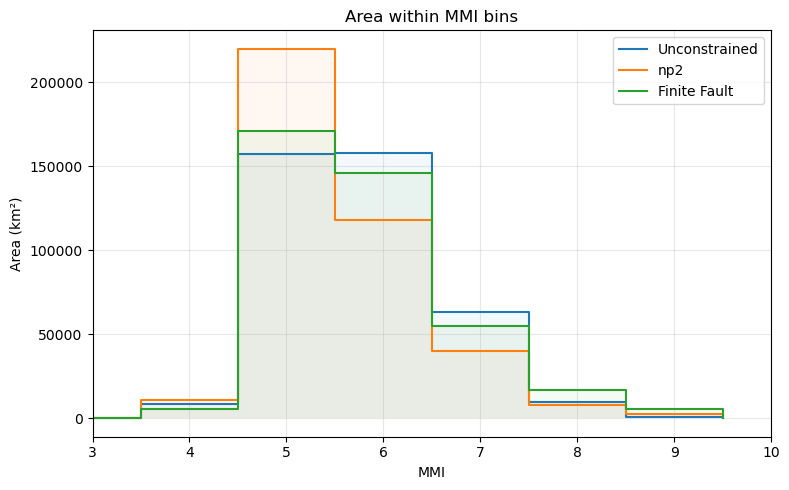

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

for i, label in enumerate(labels):
    y = bin_areas.isel(grid=i)

    ax.step(
        bin_areas["mmi"].values,
        y.values,
        where="post",
        label=label
    )

    ax.fill_between(
        bin_areas["mmi"].values,
        y.values,
        step="post",
        alpha=0.05
    )

ax.set_xlim(3, 10)
ax.set_xlabel("MMI")
ax.set_ylabel("Area (km²)")
ax.set_title("Area within MMI bins")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(f"{output}/MMI_area-intensity-dist.png", dpi=200)
plt.show()

## Plot ratio of grid to reference grid

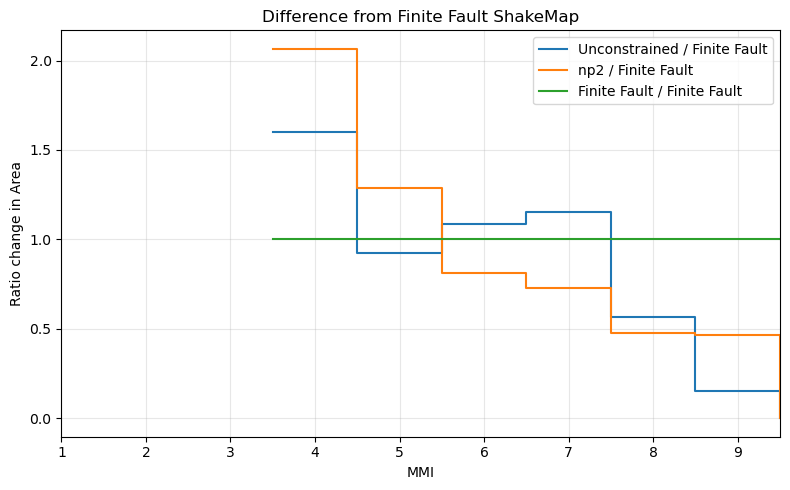

In [21]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ref_idx = n-1
ref = bin_areas.isel(grid=ref_idx)

mmi = bin_areas["mmi"].values

for i, label in enumerate(labels):
    y = bin_areas.isel(grid=i)

    # safe ratio
    delta = y / ref
    delta = delta.where(ref != 0)

    ax.step(
        mmi,
        delta.values,
        where="post",
        label=f"{label} / {labels[ref_idx]}"
    )

ax.set_xlabel("MMI")
ax.set_ylabel("Ratio change in Area")
ax.set_title(f"Difference from {labels[ref_idx]} ShakeMap")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(1.0, 9.5)

plt.tight_layout()
plt.savefig(f"{output}/MMI_area-intensity-dist_comparison.png", dpi=200)
plt.show()

## Calculate overall comparison metric


In [22]:
delta_all = bin_areas / ref
delta_all = delta_all.where(ref != 0)

# Define MMI bin geometry
mmi = bin_areas["mmi"]
bin_widths = xr.DataArray(np.diff(bin_edges), dims="mmi", coords={"mmi": mmi})

# Weighted integral
diff = np.abs(delta_all - 1)

# Fully weighted integral
mask = mmi >= 6.0
weighted_metric = (diff.where(mask) * mmi * bin_widths).sum(dim="mmi")


normalized_metric = weighted_metric / (mmi * bin_widths).sum()
normalized_metric

<xarray.DataArray (grid: 3)> Size: 24B
array([0.42310565, 0.3983358 , 0.        ])
Dimensions without coordinates: grid

/var/folders/x7/q8y3dbkj0gv831q8bnwtym_c0000gp/T/ipykernel_3679/2844737146.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to: /Users/hyin/shakemap_profiles/default/data/us6000jllz/comparison/comparison_matrix.png


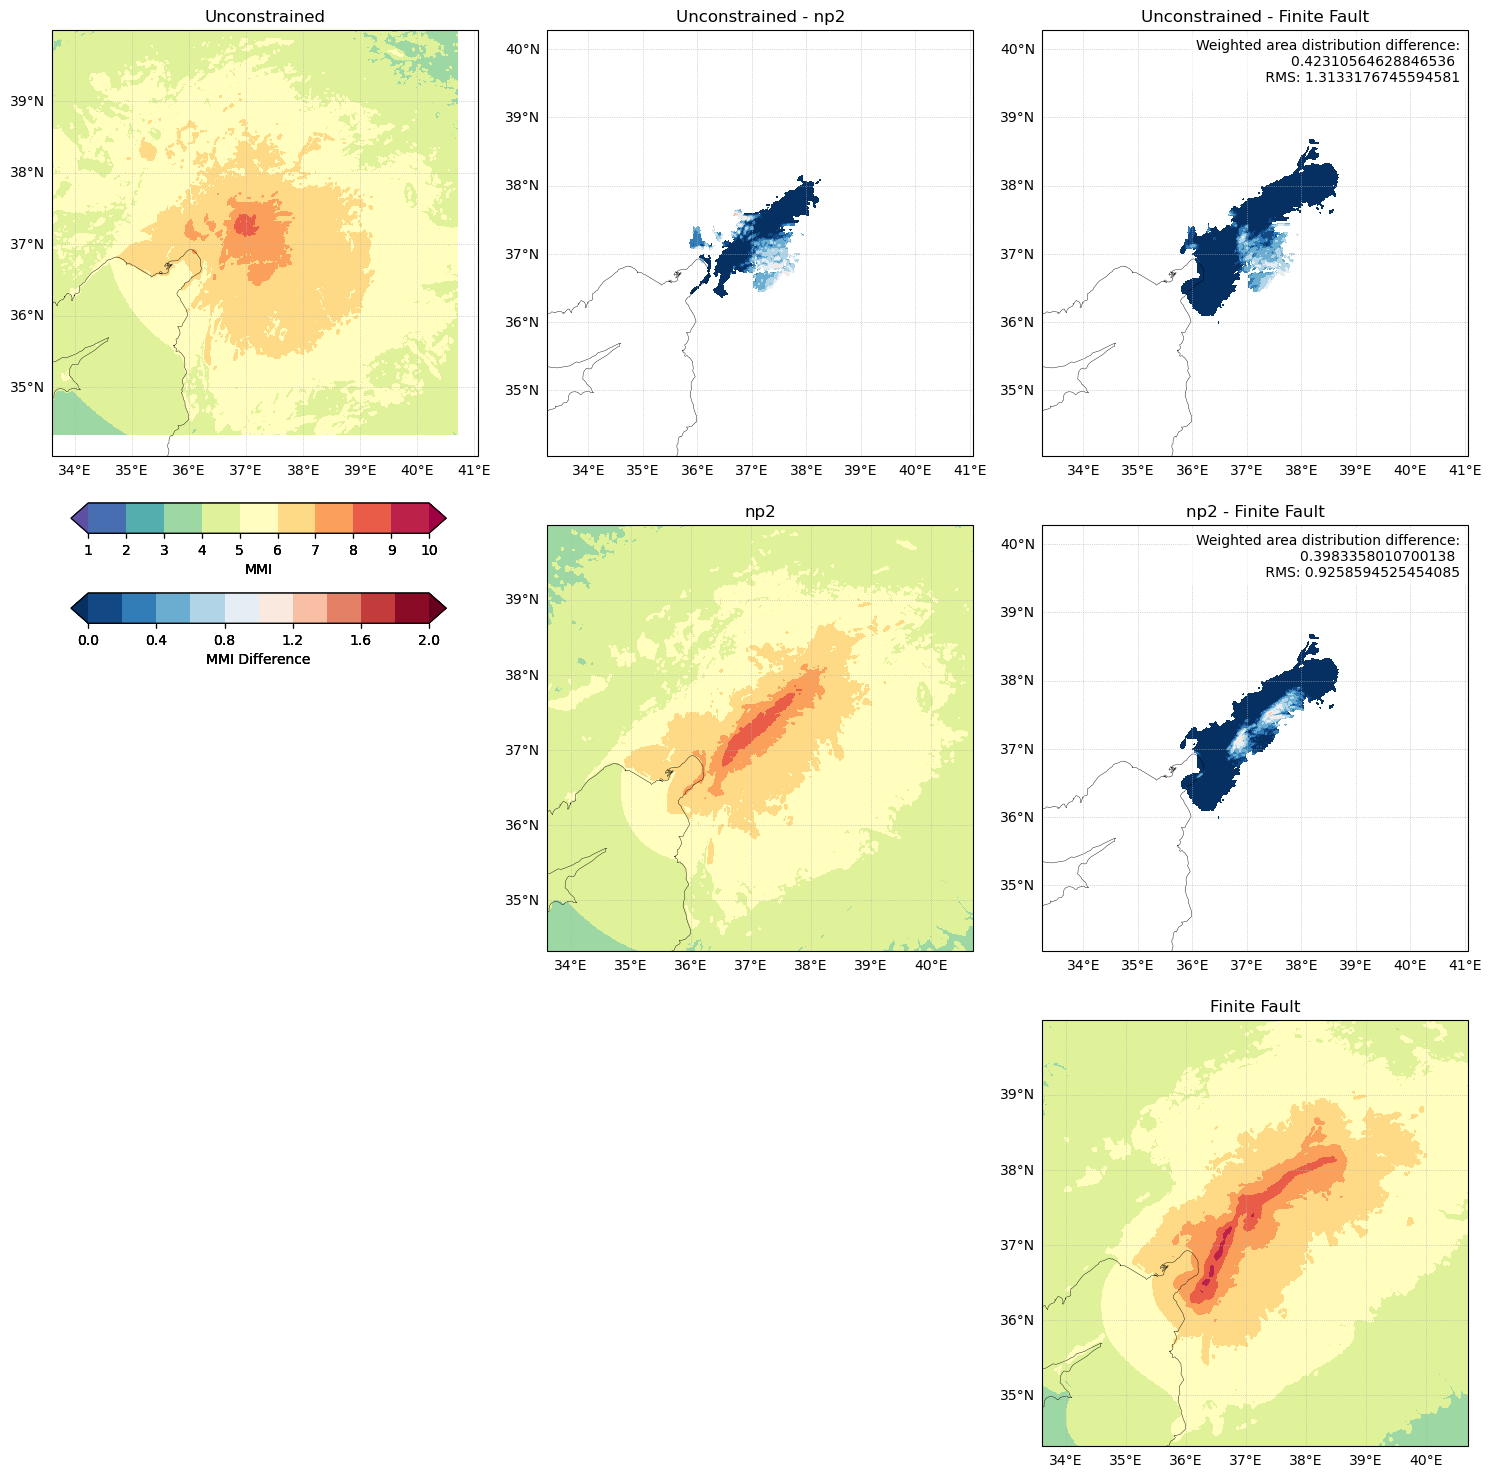

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

mmi_levels = np.linspace(1, 10, 10)
diff_levels = np.linspace(0, 2.0, 11)
threshold = 7.0

n = len(labels)


fig, axs = plt.subplots(
    n, n,
    figsize=(5*n, 5*n),
    subplot_kw={'projection': ccrs.PlateCarree()}
)


for i in range(n):
    for j in range(n):

        da_i = xr_interp[i]

        # -------------------------
        # LOWER TRIANGLE: blank
        # -------------------------
        if j < i:
            axs[i, j].set_visible(False)
            continue

        lats = da_i["lat"].values
        lons = da_i["lon"].values

        # -------------------------
        # DIAGONAL: original maps
        # -------------------------
        if i == j:

            cs = axs[i, j].contourf(
                lons, lats,
                np.flipud(da_i.values),
                mmi_levels,
                cmap=plt.cm.Spectral_r,
                extend="both"
            )

            axs[i, j].set_aspect(
                (lons.max() - lons.min()) /
                (lats.max() - lats.min())
            )

            axs[i, j].coastlines(resolution='10m', linewidth=0.3)

            gl = axs[i, j].gridlines(draw_labels=True, linewidth=0.5, linestyle='dotted')
            gl.top_labels = False
            gl.right_labels = False

            axs[i, j].set_title(labels[i])

            # colorbar (unchanged logic)
            cax1 = fig.add_axes([0.05, ((n-1)/n) - 0.03, 1/(n+1), 0.02])
            fig.colorbar(cs, cax=cax1, orientation="horizontal").set_label("MMI")

        # -------------------------
        # OFF-DIAGONAL: differences
        # -------------------------
        elif i < j:

            da_j = xr_interp[j]

            a = da_i.values.copy()
            b = da_j.values.copy()

            mask = (a < threshold) & (b < threshold)
            a[mask] = np.nan
            b[mask] = np.nan

            diff = a - b
            rms = np.sqrt(np.nanmean(diff**2))

            cs = axs[i, j].contourf(
                lons, lats,
                np.flipud(diff),
                diff_levels,
                cmap=plt.cm.RdBu_r,
                extend="both"
            )

            axs[i, j].set_aspect(
                (lons.max() - lons.min()) /
                (lats.max() - lats.min())
            )

            axs[i, j].coastlines(resolution='10m', linewidth=0.3)

            gl = axs[i, j].gridlines(draw_labels=True, linewidth=0.5, linestyle='dotted')
            gl.top_labels = False
            gl.right_labels = False

            axs[i, j].set_title(f"{labels[i]} - {labels[j]}")

            cax2 = fig.add_axes([0.05, ((n-1)/n) - 0.09, 1/(n+1), 0.02])
            fig.colorbar(cs, cax=cax2, orientation="horizontal").set_label("MMI Difference")

            # annotation
            if j == (n - 1):
                axs[i, j].text(
                    0.98, 0.98,
                    f"Weighted area distribution difference:\n{normalized_metric.data[i]} \n RMS: {rms}",
                    transform=axs[i, j].transAxes,
                    ha="right",
                    va="top",
                    fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
                )

        # -------------------------
        # LOWER TRIANGLE (redundant safety)
        # -------------------------
        else:
            axs[i, j].set_visible(False)

plt.tight_layout()
plt.savefig(f"{output}comparison_matrix.png", dpi=300)
print(f"Saved to: {output}comparison_matrix.png")

In [ ]:
# %history -g -f filename


## Recovery attempt

/var/folders/x7/q8y3dbkj0gv831q8bnwtym_c0000gp/T/ipykernel_3679/4073104556.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to: /Users/hyin/shakemap_profiles/default/data/us6000jllz/comparison/comparison_matrix.png


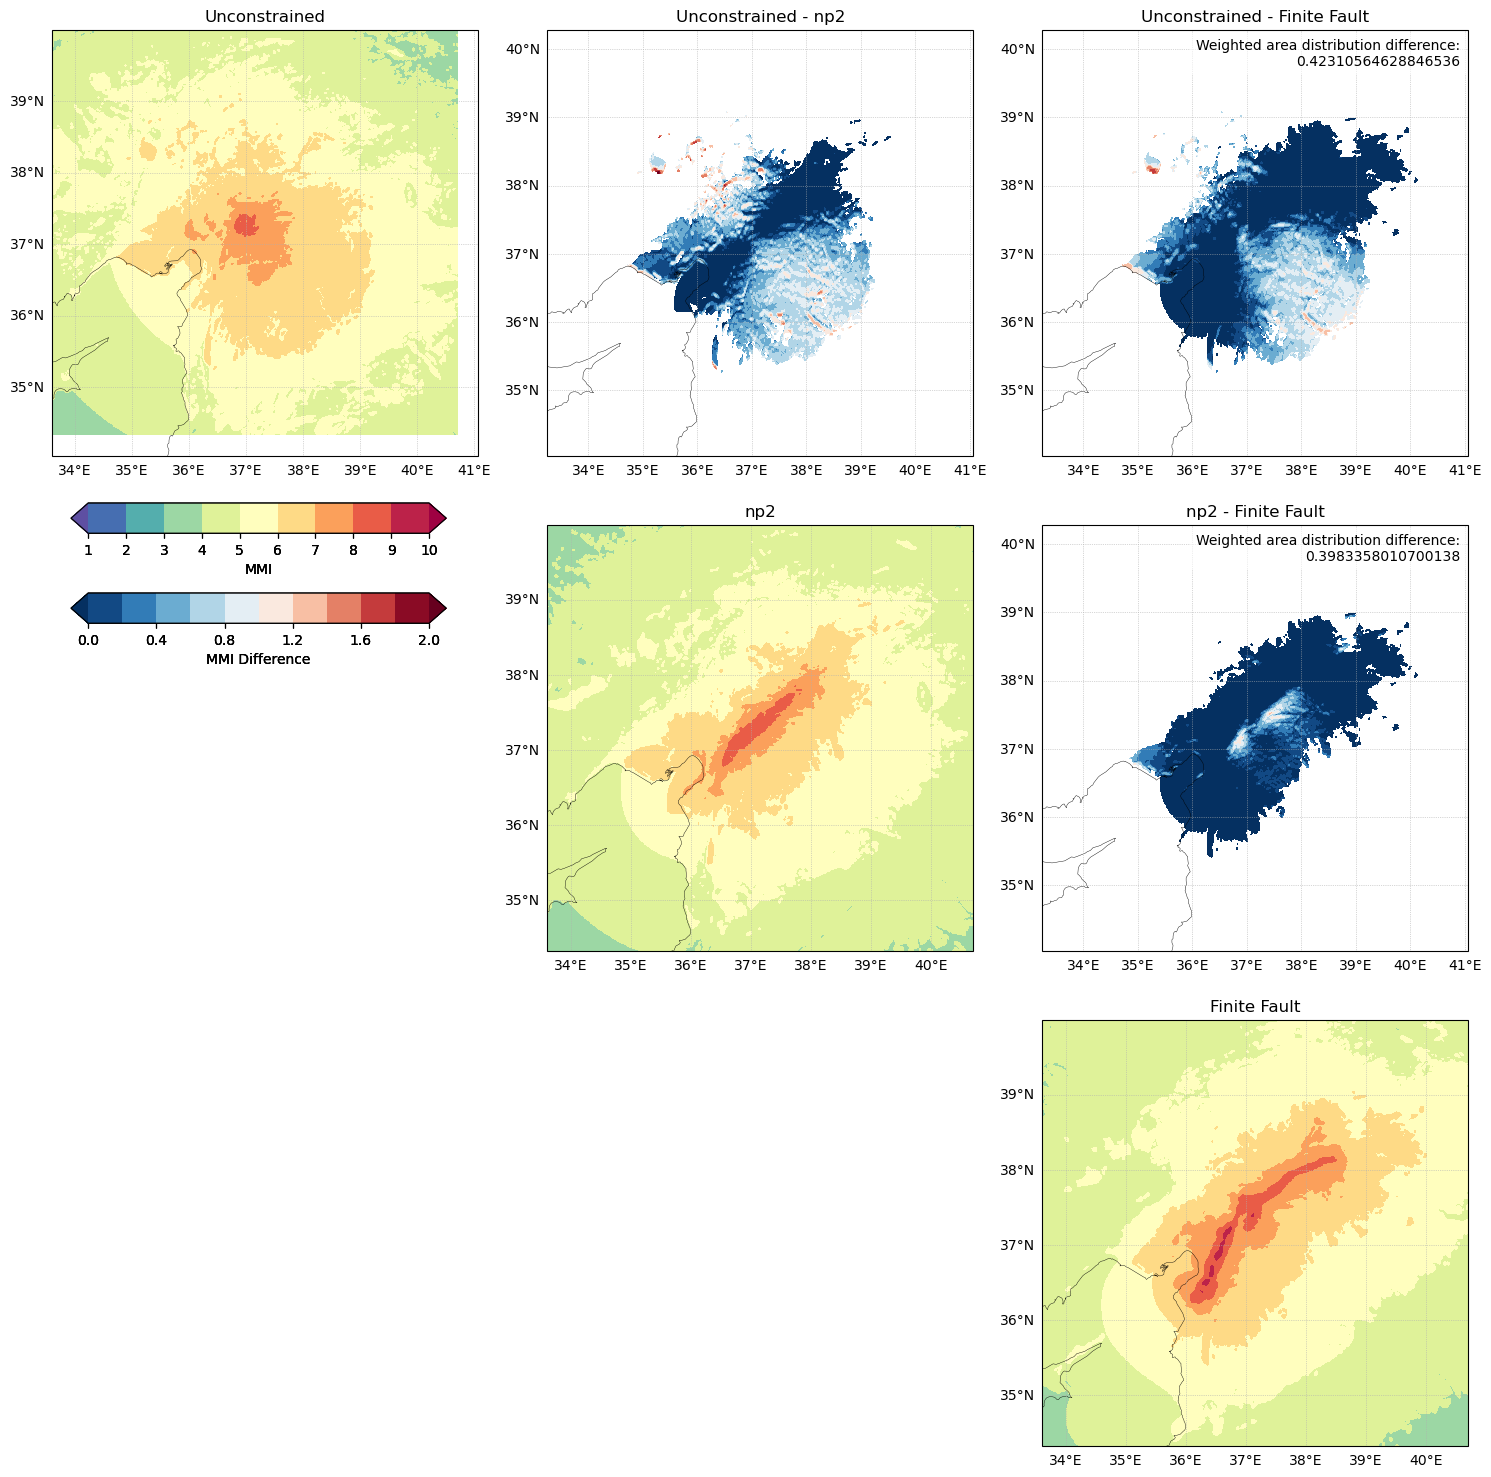

In [ ]:
delta_all = bin_areas / ref
delta_all = delta_all.where(ref != 0)
threshold = 6.0

# Define MMI bin geometry
mmi = bin_areas["mmi"]
bin_widths = xr.DataArray(np.diff(bin_edges), dims="mmi", coords={"mmi": mmi})

# Weighted integral
diff = np.abs(delta_all - 1)

# Fully weighted integral
mask = mmi >= 6.0
weighted_metric = (diff.where(mask) * mmi * bin_widths).sum(dim="mmi")


normalized_metric = weighted_metric / (mmi * bin_widths).sum()
normalized_metric

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig, axs = plt.subplots(
    n, n,
    figsize=(5*n, 5*n),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for i in range(n):
    for j in range(n):

        da_i = xr_interp[i]

        # -------------------------
        # LOWER TRIANGLE: blank
        # -------------------------
        if j < i:
            axs[i, j].set_visible(False)
            continue

        lats = da_i["lat"].values
        lons = da_i["lon"].values

        # -------------------------
        # DIAGONAL: original maps
        # -------------------------
        if i == j:

            cs = axs[i, j].contourf(
                lons, lats,
                np.flipud(da_i.values),
                mmi_levels,
                cmap=plt.cm.Spectral_r,
                extend="both"
            )

            axs[i, j].set_aspect(
                (lons.max() - lons.min()) /
                (lats.max() - lats.min())
            )

            axs[i, j].coastlines(resolution='10m', linewidth=0.3)

            gl = axs[i, j].gridlines(draw_labels=True, linewidth=0.5, linestyle='dotted')
            gl.top_labels = False
            gl.right_labels = False

            axs[i, j].set_title(labels[i])

            # colorbar (unchanged logic)
            cax1 = fig.add_axes([0.05, ((n-1)/n) - 0.03, 1/(n+1), 0.02])
            fig.colorbar(cs, cax=cax1, orientation="horizontal").set_label("MMI")

        # -------------------------
        # OFF-DIAGONAL: differences
        # -------------------------
        elif i < j:

            da_j = xr_interp[j]

            a = da_i.values.copy()
            b = da_j.values.copy()

            mask = (a < threshold) & (b < threshold)
            a[mask] = np.nan
            b[mask] = np.nan

            diff = a - b
            rms = np.sqrt(np.nanmean(diff**2))

            cs = axs[i, j].contourf(
                lons, lats,
                np.flipud(diff),
                diff_levels,
                cmap=plt.cm.RdBu_r,
                extend="both"
            )

            axs[i, j].set_aspect(
                (lons.max() - lons.min()) /
                (lats.max() - lats.min())
            )

            axs[i, j].coastlines(resolution='10m', linewidth=0.3)

            gl = axs[i, j].gridlines(draw_labels=True, linewidth=0.5, linestyle='dotted')
            gl.top_labels = False
            gl.right_labels = False

            axs[i, j].set_title(f"{labels[i]} - {labels[j]}")

            cax2 = fig.add_axes([0.05, ((n-1)/n) - 0.09, 1/(n+1), 0.02])
            fig.colorbar(cs, cax=cax2, orientation="horizontal").set_label("MMI Difference")

            # annotation
            if j == (n - 1):
                axs[i, j].text(
                    0.98, 0.98,
                    f"Weighted area distribution difference:\n{normalized_metric.data[i]}",
                    transform=axs[i, j].transAxes,
                    ha="right",
                    va="top",
                    fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
                )

        # -------------------------
        # LOWER TRIANGLE (redundant safety)
        # -------------------------
        else:
            axs[i, j].set_visible(False)

plt.tight_layout()
plt.savefig(f"{output}comparison_matrix.png", dpi=300)
print(f"Saved to: {output}comparison_matrix.png")